# 🧊 Projeto Fatorial 2³ com Replicações — Consenso entre LLMs

Extensão do projeto 2² adicionando um **terceiro fator: tamanho do texto**.
O consenso continua sendo construído **reutilizando a mesma máquina do notebook
`analise_consenso_llms_extra.ipynb`** (`ConsensusCalculator` +
`ConsensusEvaluator`).

**Fatores**

| Fator | Variável | -1 | +1 |
|-------|----------|----|----|
| **Domínio**         | **B** | MovieReview (geral) | Books (técnico)     |
| **Consenso**        | **C** | Maioria (2×1)       | Unanimidade (3×0)   |
| **Tamanho do texto**| **D** | Curto               | Longo               |

O fator **D** usa um **corte na mediana de `text_len` dentro de cada domínio**
(assim fica ortogonal a B e a C). Cada combinação tem **5 replicações** (as 5
últimas pastas de `data/results/<dataset>`).

Projeto **2³ completo com replicação** ⇒ 2³ × 5 = **40 observações**.
Efeitos estimados: principais (B, C, D) e interações (BC, BD, CD, BCD).
Respostas: **F1 Macro** e **Acurácia**.

> ⚠️ Como no projeto 2², o erro experimental é minúsculo (réplicas quase
> determinísticas), então quase tudo sai significativo. **Interprete pelo
> tamanho do efeito (2q) e pela % de variação explicada**, não pelo p-valor.

> Os modelos individuais **não** entram no projeto fatorial — servem apenas
> para benchmark posterior.


## 1) Setup e configuração

In [1]:
import os
import sys
import glob
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
)
from loguru import logger

# Localiza a raiz do projeto (a que contém data/results) e a coloca no path
ROOT = Path.cwd()
while not (ROOT / "data" / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Reutiliza a MESMA máquina de consenso do notebook analise_consenso_llms_extra
from src.llm_annotation_system.consensus.consensus_calculator import ConsensusCalculator
from src.llm_annotation_system.consensus.consensus_evaluator import ConsensusEvaluator

logger.remove()  # silencia os logs verbosos do consenso (rodamos muitas vezes)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"] = 110

MODELS = ["deepseek-r1-8b", "qwen3-8b", "llama3.1-8b"]
CONS_COLS = [f"{m}_consensus" for m in MODELS]

DATASETS = ["movie_review", "books"]   # B = -1 (movie), +1 (books)
N_REPS = 5                              # nº de replicações por dataset
INVALID = -1                            # código de predição/label inválida

RESULTS_DIR = ROOT / "data" / "results"
print("Raiz do projeto:", ROOT)
print("Resultados em  :", RESULTS_DIR)

Raiz do projeto: c:\Users\gabri\Documents\GitHub\llm-annotation
Resultados em  : c:\Users\gabri\Documents\GitHub\llm-annotation\data\results


## 2) Selecionar as 5 réplicas de cada dataset

As replicações são as **5 últimas pastas** (ordem cronológica pelo nome) de cada
dataset que contenham `annotations.csv`.

In [2]:
def last_n_replication_folders(dataset, n=N_REPS):
    folders = sorted(
        d for d in glob.glob(str(RESULTS_DIR / dataset / "*") + os.sep)
        if os.path.exists(os.path.join(d, "annotations.csv"))
    )
    chosen = folders[-n:]
    if len(chosen) < n:
        raise ValueError(f"{dataset}: encontrei só {len(chosen)} pastas (esperado {n}).")
    return chosen


REPLICATION_FOLDERS = {ds: last_n_replication_folders(ds) for ds in DATASETS}

for ds, folders in REPLICATION_FOLDERS.items():
    print(f"\n== {ds} ==")
    for i, f in enumerate(folders, start=1):
        print(f"  rep{i}: {os.path.basename(os.path.normpath(f))}")


== movie_review ==
  rep1: 2026-04-09_13-17-23
  rep2: 2026-05-17_14-44-16
  rep3: 2026-05-17_21-51-31
  rep4: 2026-05-18_06-14-02
  rep5: 2026-05-18_22-29-27

== books ==
  rep1: 2026-04-09_13-21-37
  rep2: 2026-05-20_21-44-17
  rep3: 2026-05-23_00-20-50
  rep4: 2026-05-24_20-47-50
  rep5: 2026-05-26_18-26-27


## 3) Consenso (via classe) + corte por tamanho do texto

Para cada réplica calculamos o consenso com a **mesma** dupla de classes, variando
só a estratégia:

- **2×1 — Maioria**: `majority_vote`, `threshold=0.8`.
- **3×0 — Unanimidade**: `unanimous_only`, `threshold=1.0` (sem consenso ⇒ `NaN`).

Aplicamos **a mesma limpeza do notebook de consenso** (descarta `ground_truth`
inválido, `resolved_annotation == -1` e casos `is_problematic`).

O fator **D (tamanho)** vem de um **corte na mediana de `text_len` calculada por
domínio** sobre o universo de exemplos válidos (a mediana é a mesma em todas as
réplicas, pois os textos são os mesmos):

- **Curto** = `text_len <= mediana`  (D = -1)
- **Longo** = `text_len >  mediana`  (D = +1)

In [3]:
STRAT_CFG = {
    "2x1": {"strategy": "majority_vote",  "threshold": 0.8},   # Maioria
    "3x0": {"strategy": "unanimous_only", "threshold": 1.0},   # Unanimidade
}


def get_categories(df):
    return sorted(int(v) for v in df["ground_truth"].unique() if v != INVALID)


def quality_metrics(y_true, y_pred):
    return {
        "accuracy":        accuracy_score(y_true, y_pred),
        "f1_macro":        f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":    recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def consensus_frames(df_raw, categories, consenso, output_dir):
    """Devolve (universo_valido, coberto) — ambos com text_len/ground_truth/resolved."""
    cfg = STRAT_CFG[consenso]
    calculator = ConsensusCalculator(
        consensus_threshold=cfg["threshold"],
        default_strategy=cfg["strategy"],
    )
    evaluator = ConsensusEvaluator(
        categories=categories, calculator=calculator, output_dir=output_dir,
    )
    sub = df_raw[["text_id", "text", "text_len", "ground_truth"] + CONS_COLS].copy()
    dfc = evaluator.compute_consensus(sub)

    universe = dfc[dfc["ground_truth"] != INVALID]                  # universo válido
    covered = universe[
        universe["resolved_annotation"].notna()
        & (universe["resolved_annotation"] != INVALID)
        & (~universe["is_problematic"])
    ]
    return universe, covered

## 4) Métricas por célula do projeto (dataset × réplica × consenso × tamanho)

Para cada célula calculamos **Accuracy, F1 Macro, Precision/Recall Macro** sobre o
subconjunto coberto **daquela faixa de tamanho**, e a `coverage` relativa ao
universo válido da mesma faixa.

In [4]:
LEN_LEVELS = {"curto": -1, "longo": +1}


def split_by_length(df, mediana, nivel):
    return df[df["text_len"] <= mediana] if nivel == "curto" else df[df["text_len"] > mediana]


rows = []
for ds in DATASETS:
    for rep_idx, folder in enumerate(REPLICATION_FOLDERS[ds], start=1):
        df_raw = pd.read_csv(os.path.join(folder, "annotations.csv"))
        categories = get_categories(df_raw)
        mediana = df_raw.loc[df_raw["ground_truth"] != INVALID, "text_len"].median()

        for consenso in STRAT_CFG:
            universe, covered = consensus_frames(df_raw, categories, consenso, folder)
            for nivel in LEN_LEVELS:
                uni_h = split_by_length(universe, mediana, nivel)
                cov_h = split_by_length(covered, mediana, nivel)
                y_true = cov_h["ground_truth"].astype(int)
                y_pred = cov_h["resolved_annotation"].astype(int)
                m = quality_metrics(y_true, y_pred)
                rows.append({
                    "dataset": ds, "replica": rep_idx, "consenso": consenso,
                    "tamanho": nivel, "mediana_len": mediana,
                    "coverage": len(cov_h) / len(uni_h) if len(uni_h) else 0.0,
                    "n_total": len(uni_h), "n_covered": len(cov_h),
                    **m,
                })

df_results = pd.DataFrame(rows)
print("Linhas:", len(df_results), "(esperado 2×2×2×5 = 40)")
df_results

Linhas: 40 (esperado 2×2×2×5 = 40)


,dataset,replica,consenso,tamanho,mediana_len,coverage,n_total,n_covered,accuracy,f1_macro,precision_macro,recall_macro
0,movie_review,1,2x1,curto,112.0000,0.9985,5369,5361,0.9170,0.9169,0.9174,0.9167
1,movie_review,1,2x1,longo,112.0000,0.9998,5293,5292,0.9101,0.9100,0.9101,0.9102
2,movie_review,1,3x0,curto,112.0000,0.9005,5369,4835,0.9477,0.9476,0.9480,0.9475
3,movie_review,1,3x0,longo,112.0000,0.8959,5293,4742,0.9431,0.9431,0.9431,0.9432
4,movie_review,2,2x1,curto,112.0000,0.9976,5369,5356,0.9177,0.9176,0.9180,0.9174
5,movie_review,2,2x1,longo,112.0000,1.0000,5293,5293,0.9086,0.9086,0.9086,0.9087
6,movie_review,2,3x0,curto,112.0000,0.9022,5369,4844,0.9472,0.9471,0.9475,0.9469
7,movie_review,2,3x0,longo,112.0000,0.9027,5293,4778,0.9410,0.9410,0.9410,0.9411
8,movie_review,3,2x1,curto,112.0000,0.9980,5369,5358,0.9168,0.9167,0.9171,0.9165
9,movie_review,3,2x1,longo,112.0000,0.9998,5293,5292,0.9080,0.9080,0.9080,0.9082


### Tabela 1 — Resultados por célula

In [5]:
cols_show = ["dataset", "consenso", "tamanho", "replica", "f1_macro", "accuracy",
             "precision_macro", "recall_macro", "coverage", "n_covered", "n_total"]
tabela1 = (df_results[cols_show]
           .sort_values(["dataset", "consenso", "tamanho", "replica"])
           .reset_index(drop=True))
tabela1

,dataset,consenso,tamanho,replica,f1_macro,accuracy,precision_macro,recall_macro,coverage,n_covered,n_total
0,books,2x1,curto,1,0.7082,0.7193,0.7304,0.7207,0.9795,16456,16801
1,books,2x1,curto,2,0.7055,0.7177,0.7269,0.7180,0.9801,16466,16801
2,books,2x1,curto,3,0.7099,0.7216,0.7312,0.7226,0.9788,16445,16801
3,books,2x1,curto,4,0.7090,0.7208,0.7308,0.7212,0.9796,16459,16801
4,books,2x1,curto,5,0.7083,0.7203,0.7300,0.7209,0.9794,16455,16801
5,books,2x1,longo,1,0.7583,0.7277,0.8069,0.7399,0.9855,16549,16793
6,books,2x1,longo,2,0.7580,0.7283,0.8068,0.7399,0.9866,16568,16793
7,books,2x1,longo,3,0.7567,0.7259,0.8061,0.7382,0.9876,16584,16793
8,books,2x1,longo,4,0.7572,0.7264,0.8064,0.7389,0.9867,16570,16793
9,books,2x1,longo,5,0.7586,0.7273,0.8063,0.7413,0.9874,16581,16793


## 5) Codificação do projeto fatorial 2³

| Fator | Variável | Mapa |
|-------|----------|------|
| Domínio  | **B** | MovieReview = -1, Books = +1 |
| Consenso | **C** | 2×1 = -1, 3×0 = +1 |
| Tamanho  | **D** | curto = -1, longo = +1 |

Tratamento rotulado pelas letras minúsculas dos fatores em nível +1
(`(1)` quando todos em -1): `b, c, d, bc, bd, cd, bcd`.

In [6]:
B_MAP = {"movie_review": -1, "books": +1}
C_MAP = {"2x1": -1, "3x0": +1}
D_MAP = {"curto": -1, "longo": +1}

df_results["B"] = df_results["dataset"].map(B_MAP)
df_results["C"] = df_results["consenso"].map(C_MAP)
df_results["D"] = df_results["tamanho"].map(D_MAP)


def treat_label(b, c, d):
    s = "".join(n for n, v in [("b", b), ("c", c), ("d", d)] if v == 1)
    return s if s else "(1)"


df_results["tratamento"] = [treat_label(b, c, d)
                            for b, c, d in zip(df_results["B"], df_results["C"], df_results["D"])]
df_results[["dataset", "consenso", "tamanho", "tratamento", "B", "C", "D",
            "f1_macro", "accuracy"]].head(40)

,dataset,consenso,tamanho,tratamento,B,C,D,f1_macro,accuracy
0,movie_review,2x1,curto,(1),-1,-1,-1,0.9169,0.9170
1,movie_review,2x1,longo,d,-1,-1,1,0.9100,0.9101
2,movie_review,3x0,curto,c,-1,1,-1,0.9476,0.9477
3,movie_review,3x0,longo,cd,-1,1,1,0.9431,0.9431
4,movie_review,2x1,curto,(1),-1,-1,-1,0.9176,0.9177
5,movie_review,2x1,longo,d,-1,-1,1,0.9086,0.9086
6,movie_review,3x0,curto,c,-1,1,-1,0.9471,0.9472
7,movie_review,3x0,longo,cd,-1,1,1,0.9410,0.9410
8,movie_review,2x1,curto,(1),-1,-1,-1,0.9167,0.9168
9,movie_review,2x1,longo,d,-1,-1,1,0.9080,0.9080


## 6) Função genérica de análise fatorial 2^k com replicação

Modelo: $y = q_0 + \sum_i q_i x_i + \sum_{i<j} q_{ij} x_i x_j + \dots + e$

- $q_{efeito} = \dfrac{\sum (x\,\text{do contraste})\cdot y}{N}$, com $N = 2^k r = 40$
- **Efeito** $= 2 q$ ; $SS = N q^2$ ; $SST = \sum (y-\bar{y})^2$
- $SSE = SST - \sum SS_{efeitos}$ ; $g.l._{erro} = 2^k(r-1) = 32$
- $s_e^2 = SSE/g.l._{erro}$ ; $s_q = \sqrt{s_e^2/N}$
- $t = q/s_q$ ; IC: $q \pm t_{1-\alpha/2;\,g.l.}\, s_q$

In [7]:
def factorial_2k_analysis(data, response, factors, r=N_REPS, alpha=0.05):
    """Análise fatorial 2^k completa (todos os efeitos principais e interações)."""
    d = data.copy()
    y = d[response].to_numpy(dtype=float)
    k = len(factors)
    N = (2 ** k) * r
    assert len(d) == N, f"Esperado {N} observações, obtidas {len(d)}"

    # ---- colunas de contraste de cada efeito (produtos dos fatores) ---
    effect_names, effect_cols = [], {}
    for size in range(1, k + 1):
        for combo in combinations(factors, size):
            name = "".join(combo)
            col = np.ones(N)
            for f in combo:
                col = col * d[f].to_numpy(dtype=float)
            effect_names.append(name)
            effect_cols[name] = col

    # ---- médias por tratamento --------------------------------------
    means = (d.groupby(["tratamento"] + factors)[response]
               .agg(media="mean", std="std", var="var", n="count")
               .reset_index())

    # ---- q, SS e significância --------------------------------------
    q0 = y.mean()
    SST = ((y - y.mean()) ** 2).sum()
    df_err = (2 ** k) * (r - 1)

    qs, SS = {}, {}
    for name in effect_names:
        q = (effect_cols[name] * y).sum() / N
        qs[name] = q
        SS[name] = N * q ** 2

    SSE = SST - sum(SS.values())
    s2e = SSE / df_err
    s_q = np.sqrt(s2e / N)
    t_crit = stats.t.ppf(1 - alpha / 2, df_err)

    sig_rows = []
    for name in effect_names:
        q, ss = qs[name], SS[name]
        t_val = q / s_q if s_q > 0 else np.nan
        p_val = 2 * stats.t.sf(abs(t_val), df_err) if s_q > 0 else np.nan
        sig_rows.append({
            "efeito": name,
            "q": q,
            "efeito (2q)": 2 * q,
            "IC q low":  q - t_crit * s_q,
            "IC q high": q + t_crit * s_q,
            "t": t_val,
            "p_value": p_val,
            "signif. (5%)": bool(p_val < alpha) if not np.isnan(p_val) else False,
            "SS": ss,
            "% variação": 100 * ss / SST if SST > 0 else np.nan,
        })
    significance = pd.DataFrame(sig_rows)

    effects = significance[["efeito", "q", "efeito (2q)", "% variação"]].copy()

    ss_table = pd.DataFrame(
        [{"componente": n, "SS": SS[n], "g.l.": 1, "% variação": 100 * SS[n] / SST}
         for n in effect_names]
        + [{"componente": "Erro", "SS": SSE, "g.l.": df_err, "% variação": 100 * SSE / SST},
           {"componente": "Total", "SS": SST, "g.l.": N - 1, "% variação": 100.0}]
    )

    return {
        "response": response, "means": means, "effects": effects,
        "significance": significance, "ss_table": ss_table,
        "q0": q0, "s2e": s2e, "s_q": s_q, "SSE": SSE, "SST": SST,
        "df_err": df_err, "t_crit": t_crit, "N": N,
    }


FACTORS = ["B", "C", "D"]

## 7) Funções de gráfico (efeitos principais e interações)

In [8]:
LAB = {
    "B": {-1: "MovieReview", +1: "Books"},
    "C": {-1: "Maioria (2×1)", +1: "Unanimidade (3×0)"},
    "D": {-1: "Curto", +1: "Longo"},
}
FACTOR_NAME = {"B": "Domínio", "C": "Consenso", "D": "Tamanho"}


def main_effect_plot(data, factor, response, ax):
    g = data.groupby(factor)[response].mean()
    xs = sorted(g.index)
    ax.plot([LAB[factor][x] for x in xs], [g[x] for x in xs], "o-", lw=2, ms=9, color="#2c6fbb")
    for x in xs:
        ax.annotate(f"{g[x]:.4f}", (LAB[factor][x], g[x]),
                    textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
    ax.set_title(f"Efeito principal — {FACTOR_NAME[factor]} ({factor})")
    ax.set_ylabel(f"Média de {response}")
    ax.grid(alpha=0.3)


def interaction_plot(data, f1, f2, response, ax):
    colors = {-1: "#2c6fbb", +1: "#d1495b"}
    for lvl in (-1, +1):
        sub = data[data[f2] == lvl].groupby(f1)[response].mean()
        xs = sorted(sub.index)
        ax.plot([LAB[f1][x] for x in xs], [sub[x] for x in xs], "o-", lw=2, ms=9,
                color=colors[lvl], label=f"{FACTOR_NAME[f2]}: {LAB[f2][lvl]}")
    ax.set_title(f"Interação {FACTOR_NAME[f1]} × {FACTOR_NAME[f2]} ({f1}{f2})")
    ax.set_ylabel(f"Média de {response}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)


def plot_factorial(data, response):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, f in zip(axes[0], FACTORS):
        main_effect_plot(data, f, response, ax)
    for ax, (f1, f2) in zip(axes[1], [("B", "C"), ("B", "D"), ("C", "D")]):
        interaction_plot(data, f1, f2, response, ax)
    fig.suptitle(f"Projeto fatorial 2³ — resposta: {response}", fontsize=13)
    plt.tight_layout()
    plt.show()

## 8) Análise fatorial 2³ — Resposta = **F1 Macro**

In [9]:
res_f1 = factorial_2k_analysis(df_results, "f1_macro", FACTORS)
print(f"s²_e = {res_f1['s2e']:.6e}   s_q = {res_f1['s_q']:.6e}   "
      f"g.l. erro = {res_f1['df_err']}   t_crit(5%) = {res_f1['t_crit']:.4f}")

s²_e = 2.123537e-06   s_q = 2.304093e-04   g.l. erro = 32   t_crit(5%) = 2.0369


### Tabela 2 — Médias dos 8 tratamentos (F1)

In [10]:
res_f1["means"]

,tratamento,B,C,D,media,std,var,n
0,(1),-1,-1,-1,0.9171,0.0007,0.0000,5
1,b,1,-1,-1,0.7082,0.0017,0.0000,5
2,bc,1,1,-1,0.7711,0.0023,0.0000,5
3,bcd,1,1,1,0.8176,0.0018,0.0000,5
4,bd,1,-1,1,0.7578,0.0008,0.0000,5
5,c,-1,1,-1,0.9464,0.0013,0.0000,5
6,cd,-1,1,1,0.9420,0.0014,0.0000,5
7,d,-1,-1,1,0.9091,0.0010,0.0000,5


### Tabela 3 — Efeitos fatoriais (F1)

In [11]:
res_f1["effects"]

,efeito,q,efeito (2q),% variação
0,B,-0.0825,-0.1650,88.4640
1,C,0.0231,0.0462,6.9507
2,D,0.0105,0.0209,1.4254
3,BC,0.0076,0.0151,0.7459
4,BD,0.0135,0.0271,2.3826
5,CD,0.0001,0.0001,0.0000
6,BCD,-0.0008,-0.0017,0.0093


### Tabela 4 — Significância estatística (F1)

In [12]:
res_f1["significance"]

,efeito,q,efeito (2q),IC q low,IC q high,t,p_value,signif. (5%),SS,% variação
0,B,-0.0825,-0.1650,-0.0830,-0.0820,-358.0165,0.0000,True,0.2722,88.4640
1,C,0.0231,0.0462,0.0227,0.0236,100.3537,0.0000,True,0.0214,6.9507
2,D,0.0105,0.0209,0.0100,0.0109,45.4455,0.0000,True,0.0044,1.4254
3,BC,0.0076,0.0151,0.0071,0.0080,32.8751,0.0000,True,0.0023,0.7459
4,BD,0.0135,0.0271,0.0131,0.0140,58.7545,0.0000,True,0.0073,2.3826
5,CD,0.0001,0.0001,-0.0004,0.0005,0.2527,0.8021,False,0.0000,0.0000
6,BCD,-0.0008,-0.0017,-0.0013,-0.0004,-3.6622,0.0009,True,0.0000,0.0093


### Decomposição da variação (F1)

In [13]:
res_f1["ss_table"]

,componente,SS,g.l.,% variação
0,B,0.2722,1,88.4640
1,C,0.0214,1,6.9507
2,D,0.0044,1,1.4254
3,BC,0.0023,1,0.7459
4,BD,0.0073,1,2.3826
5,CD,0.0000,1,0.0000
6,BCD,0.0000,1,0.0093
7,Erro,0.0001,32,0.0221
8,Total,0.3077,39,100.0000


### Gráficos — F1 Macro

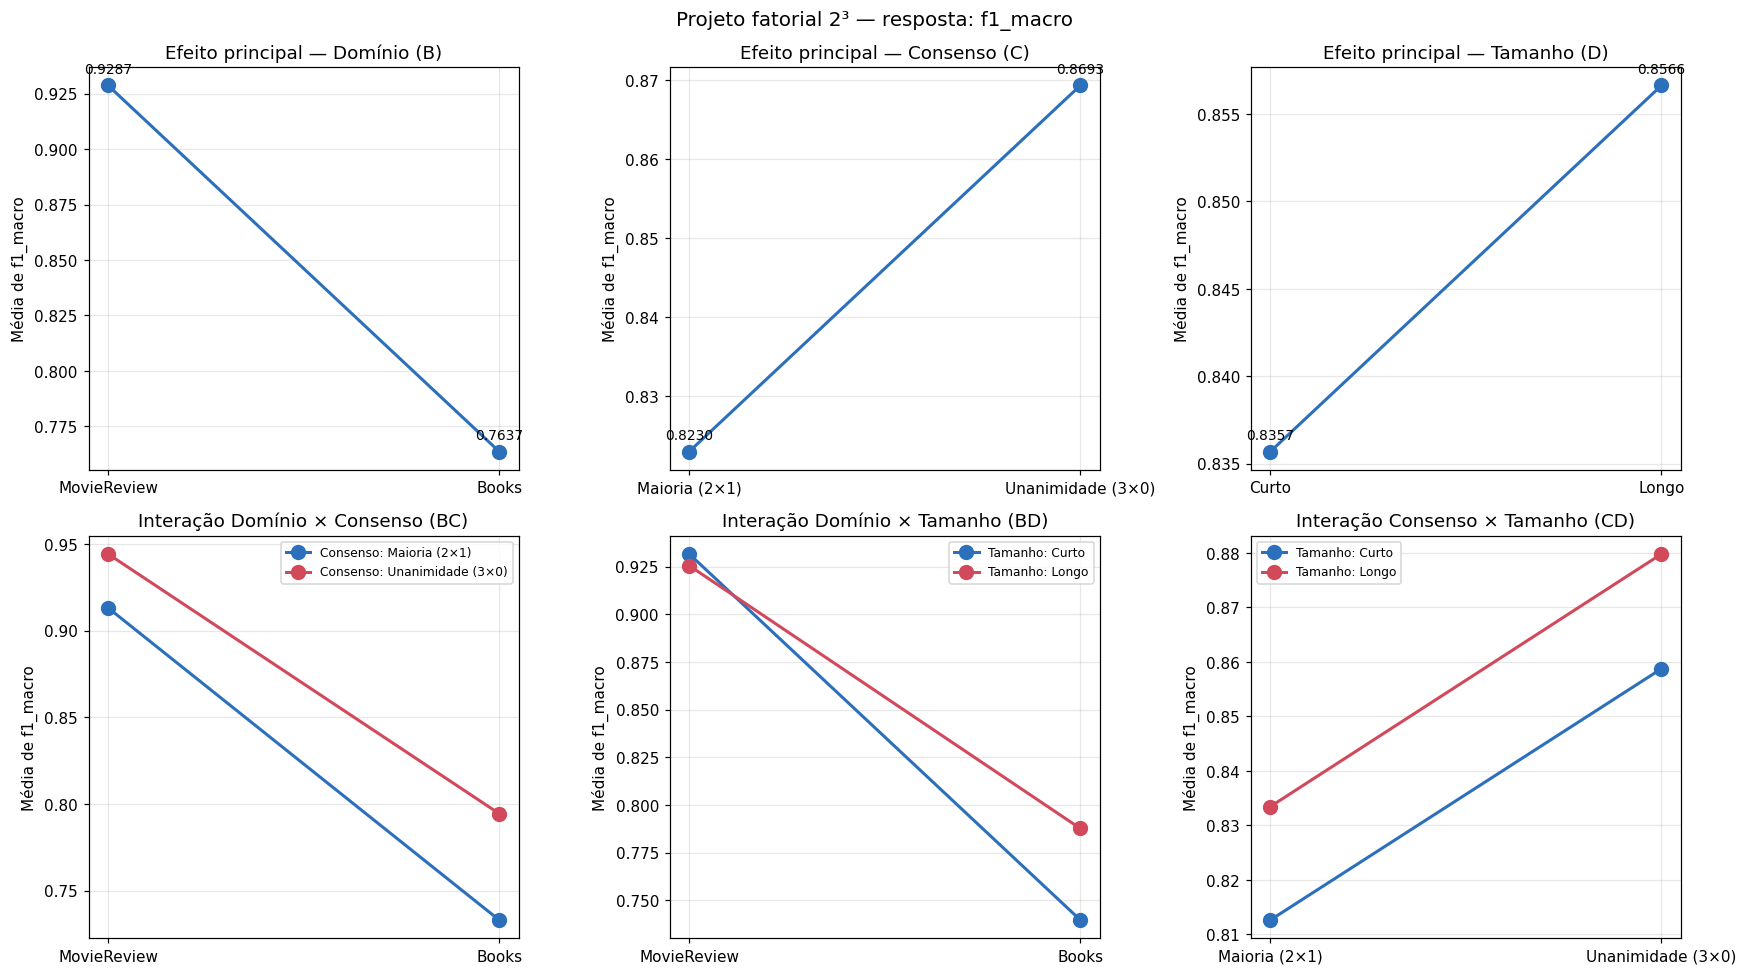

In [14]:
plot_factorial(df_results, "f1_macro")

## 9) Análise fatorial 2³ — Resposta = **Acurácia**

In [15]:
res_acc = factorial_2k_analysis(df_results, "accuracy", FACTORS)
print(f"s²_e = {res_acc['s2e']:.6e}   s_q = {res_acc['s_q']:.6e}   "
      f"g.l. erro = {res_acc['df_err']}   t_crit(5%) = {res_acc['t_crit']:.4f}")

s²_e = 2.105149e-06   s_q = 2.294095e-04   g.l. erro = 32   t_crit(5%) = 2.0369


### Médias dos 8 tratamentos (Acurácia)

In [16]:
res_acc["means"]

,tratamento,B,C,D,media,std,var,n
0,(1),-1,-1,-1,0.9172,0.0007,0.0000,5
1,b,1,-1,-1,0.7199,0.0015,0.0000,5
2,bc,1,1,-1,0.7931,0.0026,0.0000,5
3,bcd,1,1,1,0.7922,0.0014,0.0000,5
4,bd,1,-1,1,0.7271,0.0009,0.0000,5
5,c,-1,1,-1,0.9464,0.0013,0.0000,5
6,cd,-1,1,1,0.9420,0.0014,0.0000,5
7,d,-1,-1,1,0.9091,0.0010,0.0000,5


### Efeitos fatoriais (Acurácia)

In [17]:
res_acc["effects"]

,efeito,q,efeito (2q),% variação
0,B,-0.0853,-0.1706,90.9061
1,C,0.0250,0.0501,7.8374
2,D,-0.0008,-0.0015,0.0072
3,BC,0.0095,0.0190,1.1293
4,BD,0.0023,0.0047,0.0681
5,CD,-0.0006,-0.0011,0.0039
6,BCD,-0.0015,-0.0029,0.0269


### Significância estatística (Acurácia)

In [18]:
res_acc["significance"]

,efeito,q,efeito (2q),IC q low,IC q high,t,p_value,signif. (5%),SS,% variação
0,B,-0.0853,-0.1706,-0.0858,-0.0848,-371.8169,0.0000,True,0.2910,90.9061
1,C,0.0250,0.0501,0.0246,0.0255,109.1736,0.0000,True,0.0251,7.8374
2,D,-0.0008,-0.0015,-0.0012,-0.0003,-3.3078,0.0023,True,0.0000,0.0072
3,BC,0.0095,0.0190,0.0090,0.0100,41.4417,0.0000,True,0.0036,1.1293
4,BD,0.0023,0.0047,0.0019,0.0028,10.1802,0.0000,True,0.0002,0.0681
5,CD,-0.0006,-0.0011,-0.0010,-0.0001,-2.4342,0.0207,True,0.0000,0.0039
6,BCD,-0.0015,-0.0029,-0.0019,-0.0010,-6.3957,0.0000,True,0.0001,0.0269


### Decomposição da variação (Acurácia)

In [19]:
res_acc["ss_table"]

,componente,SS,g.l.,% variação
0,B,0.2910,1,90.9061
1,C,0.0251,1,7.8374
2,D,0.0000,1,0.0072
3,BC,0.0036,1,1.1293
4,BD,0.0002,1,0.0681
5,CD,0.0000,1,0.0039
6,BCD,0.0001,1,0.0269
7,Erro,0.0001,32,0.0210
8,Total,0.3201,39,100.0000


### Gráficos — Acurácia

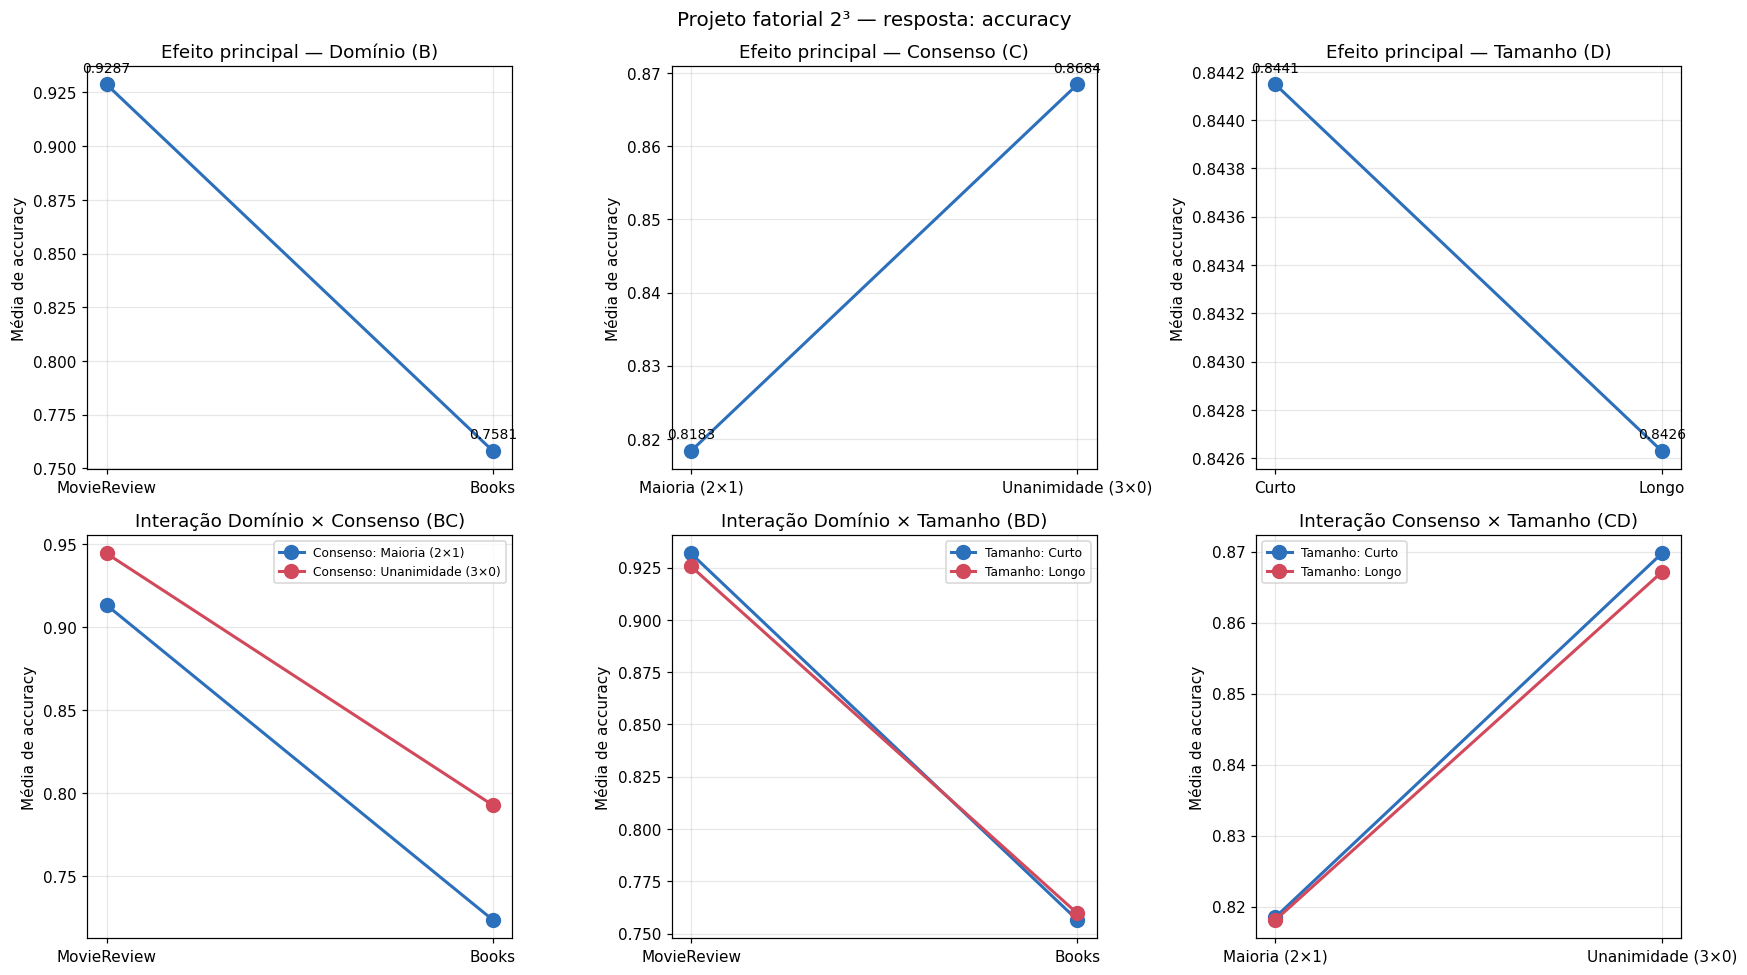

In [20]:
plot_factorial(df_results, "accuracy")

## 10) Resumo / interpretação

- **B (Domínio)**, **C (Consenso)** e **D (Tamanho)** são os efeitos principais.
- **BC, BD, CD, BCD** são as interações — em especial **BD** (o efeito do tamanho
  depende do domínio?) e **CD** (o tamanho importa mais sob maioria ou
  unanimidade?).
- Leia pelo **tamanho do efeito (2q)** e pela **% de variação**: o erro
  experimental é ínfimo, então o p-valor satura em "significativo".
- A linha **Erro** das tabelas de decomposição mostra a % de variação residual.

In [21]:
def resumo(res, titulo):
    err_pct = 100 * res["SSE"] / res["SST"]
    print(f"=== RESUMO {titulo} ===")
    cols = ["efeito", "efeito (2q)", "t", "p_value", "signif. (5%)", "% variação"]
    print(res["significance"][cols].to_string(index=False))
    print(f"\nErro experimental: s²_e = {res['s2e']:.3e} | "
          f"SSE = {res['SSE']:.6f} | % variação (erro) = {err_pct:.4f}%")


resumo(res_f1, "F1 MACRO")
print()
resumo(res_acc, "ACURÁCIA")

=== RESUMO F1 MACRO ===
efeito  efeito (2q)         t  p_value  signif. (5%)  % variação
     B      -0.1650 -358.0165   0.0000          True     88.4640
     C       0.0462  100.3537   0.0000          True      6.9507
     D       0.0209   45.4455   0.0000          True      1.4254
    BC       0.0151   32.8751   0.0000          True      0.7459
    BD       0.0271   58.7545   0.0000          True      2.3826
    CD       0.0001    0.2527   0.8021         False      0.0000
   BCD      -0.0017   -3.6622   0.0009          True      0.0093

Erro experimental: s²_e = 2.124e-06 | SSE = 0.000068 | % variação (erro) = 0.0221%

=== RESUMO ACURÁCIA ===
efeito  efeito (2q)         t  p_value  signif. (5%)  % variação
     B      -0.1706 -371.8169   0.0000          True     90.9061
     C       0.0501  109.1736   0.0000          True      7.8374
     D      -0.0015   -3.3078   0.0023          True      0.0072
    BC       0.0190   41.4417   0.0000          True      1.1293
    BD       0.0047   

In [22]:
# ===== Exportar análises em .json (data/results/mq/fatorial_2x2x2) =====
import json

EXPORT_DIR = ROOT / "data" / "results" / "mq" / "fatorial_2x2x2"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def _to_jsonable(o):
    if isinstance(o, pd.DataFrame):
        return o.to_dict(orient="records")
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return float(o)
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, dict):
        return {k: _to_jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_to_jsonable(v) for v in o]
    return o


payload = {
    "design": "2^3 (B=domínio, C=consenso, D=tamanho do texto)",
    "fatores": {
        "B": {"-1": "movie_review", "+1": "books"},
        "C": {"-1": "2x1 (maioria)", "+1": "3x0 (unanimidade)"},
        "D": {"-1": "curto", "+1": "longo"},
    },
    "n_replicas": N_REPS,
    "resultados_por_celula": _to_jsonable(df_results),
    "analise": {
        "f1_macro": _to_jsonable(res_f1),
        "accuracy": _to_jsonable(res_acc),
    },
}

with open(EXPORT_DIR / "analise_fatorial_2x2x2.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)
with open(EXPORT_DIR / "resultados_por_celula.json", "w", encoding="utf-8") as f:
    json.dump(_to_jsonable(df_results), f, ensure_ascii=False, indent=2)

print("✓ Análises salvas em:", EXPORT_DIR)
for p in sorted(EXPORT_DIR.glob("*.json")):
    print("  -", p.name)


✓ Análises salvas em: c:\Users\gabri\Documents\GitHub\llm-annotation\data\results\mq\fatorial_2x2x2
  - analise_fatorial_2x2x2.json
  - resultados_por_celula.json
